# 12b — Caruana Ensemble vs. Control: Pre-Submission Comparison

**REVISED IN PLACE 2026-09-04** -- not yet committed, so this revision
overwrites rather than adding a new numbered file. The original run of this
notebook found notebook 12's (then-uncapped) Caruana ensemble compressed
blind prediction spread relative to 10c on **every** isoform. That finding
motivated `11b_caruana_selection.ipynb`'s revision (a marginal-value-informed
size cap per isoform, user-confirmed) and notebook 12's revision (rebuilt
submission using the capped weights). This revision reruns the same
comparison against the **capped** submission candidate, and additionally
loads the **previous (uncapped) submission**, preserved at
`outputs/12_caruana_retrain_predict/submission_candidate_uncapped.csv`, so
the capping's actual effect on compression can be shown directly --
before-vs-after, not just capped-vs-10c.

## What this notebook can and cannot tell you

**This notebook CANNOT predict whether notebook 12's submission will score
better than 10c's on the blind leaderboard.** No true blind-set labels exist
yet — OpenADMET releases them only when the challenge closes (2026-11-03) —
and none are read, approximated, or invented anywhere below. Nothing in this
notebook is an accuracy forecast.

Its purposes, this revision:

1. **Checking whether notebook 12's (now capped) ensemble still repeats the
   specific, already-diagnosed spread-compression pattern** that contributed
   to notebook 10's regression (`10b` Section 3) -- and, new this revision,
   **confirming the cap actually reduced compression relative to the
   previous uncapped submission**, not just theoretically expected to.
2. **A plain description of how much notebook 12's (capped) predictions
   actually differ from `10c`'s** — a sanity check before spending a
   submission, not a quality judgment.

## Scope

Reads: `outputs/10c_control_submission/submission_candidate.csv`,
`outputs/12_caruana_retrain_predict/submission_candidate.csv` (capped,
current), `outputs/12_caruana_retrain_predict/submission_candidate_uncapped
.csv` (the previous version, for the before/after check -- new this
revision), and `train_inhibition_curated.csv` (for the true-label
training-population std — the same reference point `10b`'s Section 3 used).
No training, no test-set labels, no script — reporting only.

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))  # so `from src... import ...` works regardless of cwd

import importlib.metadata

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import pearsonr

from src.vendor.openadmet_eval.config import REGRESSION_ENDPOINTS

print(f"python: {sys.version.split()[0]}")
for pkg in ["numpy", "pandas", "scipy", "matplotlib"]:
    print(f"{pkg}: {importlib.metadata.version(pkg)}")
print(f"REGRESSION_ENDPOINTS: {REGRESSION_ENDPOINTS}")

PROCESSED = REPO_ROOT / "data" / "processed"
SUBMISSION_10C = REPO_ROOT / "outputs" / "10c_control_submission" / "submission_candidate.csv"
SUBMISSION_12 = REPO_ROOT / "outputs" / "12_caruana_retrain_predict" / "submission_candidate.csv"
SUBMISSION_12_UNCAPPED = REPO_ROOT / "outputs" / "12_caruana_retrain_predict" / "submission_candidate_uncapped.csv"
CURATED_PATH = PROCESSED / "train_inhibition_curated.csv"
WEIGHTS_PATH = REPO_ROOT / "outputs" / "11b_caruana_selection" / "weights.csv"

OUT = REPO_ROOT / "outputs" / "12b_caruana_vs_control_comparison"
FIG_OUT = OUT / "figures"
OUT.mkdir(parents=True, exist_ok=True)
FIG_OUT.mkdir(parents=True, exist_ok=True)

curated = pd.read_csv(CURATED_PATH)
print(f"\nloaded {CURATED_PATH.name}: {curated.shape}")

sub_10c = pd.read_csv(SUBMISSION_10C)
print(f"loaded {SUBMISSION_10C.relative_to(REPO_ROOT)}: {sub_10c.shape}")
sub_12 = pd.read_csv(SUBMISSION_12)
print(f"loaded {SUBMISSION_12.relative_to(REPO_ROOT)}: {sub_12.shape} (capped, current)")
sub_12_uncapped = pd.read_csv(SUBMISSION_12_UNCAPPED)
print(f"loaded {SUBMISSION_12_UNCAPPED.relative_to(REPO_ROOT)}: {sub_12_uncapped.shape} (previous, uncapped)")


python: 3.11.13
numpy: 1.26.4
pandas: 2.3.3
scipy: 1.17.1
matplotlib: 3.11.1
REGRESSION_ENDPOINTS: ['CYP1A2_pIC50_direct_inhibition', 'CYP2C9_pIC50_direct_inhibition', 'CYP2D6_pIC50_direct_inhibition', 'CYP3A4_pIC50_direct_inhibition']

loaded train_inhibition_curated.csv: (4905, 20)
loaded outputs/10c_control_submission/submission_candidate.csv: (750, 6)
loaded outputs/12_caruana_retrain_predict/submission_candidate.csv: (750, 6) (capped, current)
loaded outputs/12_caruana_retrain_predict/submission_candidate_uncapped.csv: (750, 6) (previous, uncapped)


## Alignment check -- stop conditions

All three files must have all four `{CYP}_pIC50_direct_inhibition` columns
and the exact same 750 `Molecule_Name` compounds, with no duplicates --
checked explicitly before anything else, per this task's own stop
condition. All three are merged on `Molecule_Name` (not assumed to share row
order) so every comparison below is guaranteed 1:1-correct even if the
underlying notebooks wrote rows in different orders.

In [2]:
required_cols = {"Molecule_Name", *REGRESSION_ENDPOINTS}
for name, df in [("10c", sub_10c), ("12", sub_12), ("12_uncapped", sub_12_uncapped)]:
    missing = required_cols - set(df.columns)
    if missing:
        raise ValueError(f"{name} submission_candidate.csv is missing expected column(s): {missing} -- stopping.")
print("column check passed: all three files have Molecule_Name + all 4 isoform columns")

for name, df in [("10c", sub_10c), ("12", sub_12), ("12_uncapped", sub_12_uncapped)]:
    if len(df) != 750:
        raise ValueError(f"{name}: expected 750 rows, got {len(df)} -- stopping.")
    if df["Molecule_Name"].duplicated().any():
        raise ValueError(f"{name}: duplicated Molecule_Name found -- stopping.")
if not (set(sub_10c["Molecule_Name"]) == set(sub_12["Molecule_Name"]) == set(sub_12_uncapped["Molecule_Name"])):
    raise ValueError("the three submission files do not cover the exact same 750 compounds -- stopping.")
print("row-count / duplicate / compound-set check passed: 750 compounds, identical sets, no duplicates, all three files")

merged = sub_10c[["Molecule_Name", *REGRESSION_ENDPOINTS]].merge(
    sub_12[["Molecule_Name", *REGRESSION_ENDPOINTS]], on="Molecule_Name", suffixes=("__10c", "__12"),
).merge(
    sub_12_uncapped[["Molecule_Name", *REGRESSION_ENDPOINTS]].rename(columns={c: f"{c}__12_uncapped" for c in REGRESSION_ENDPOINTS}),
    on="Molecule_Name",
)
if len(merged) != 750:
    raise ValueError(f"merge produced {len(merged)} rows, expected 750 -- stopping.")
print(f"\nmerged 10c+12+12_uncapped on Molecule_Name: {merged.shape} -- all downstream comparisons use this 1:1-aligned table")


column check passed: all three files have Molecule_Name + all 4 isoform columns
row-count / duplicate / compound-set check passed: 750 compounds, identical sets, no duplicates, all three files

merged 10c+12+12_uncapped on Molecule_Name: (750, 13) -- all downstream comparisons use this 1:1-aligned table


**What this shows:** all three files pass every alignment check -- correct
columns, 750 rows each, no duplicates, identical compound sets. Safe to
compare directly.

## Section 1 — spread comparison (the direct repeat-of-10 check, before/after capping)

Per isoform: std of the true pIC50 in the full 4,905-compound training set
(same reference point `10b` Section 3 used -- **only the training-set std is
used as a reference; blind-population spread is not available in this repo
and is not substituted for or approximated**), std of `10c`'s blind
predictions, std of notebook 12's **previous (uncapped)** blind predictions,
and std of notebook 12's **current (capped)** blind predictions. Two checks:
**whether 12-capped's spread is still narrower than 10c's** (the original
repeat-of-10 check), and **whether capping actually widened 12's spread
relative to its own uncapped predecessor** (confirming the cap's intended
effect, not just assuming it).

Section 1 -- training-true std vs 10c/12-uncapped/12-capped prediction std:
isoform  std_train  std_10c   std_12  std_12_uncapped  12_narrower_than_10c  capping_widened_spread
 CYP1A2   1.030476 0.861623 0.555969         0.545521                  True                    True
 CYP2C9   0.782295 0.778405 0.638953         0.588060                  True                    True
 CYP2D6   0.916096 0.641710 0.365271         0.357932                  True                    True
 CYP3A4   1.093219 1.019663 0.848695         0.828203                  True                    True

FLAGGED -- 12 (capped)'s spread is STILL NARROWER than 10c's for: ['CYP1A2', 'CYP2C9', 'CYP2D6', 'CYP3A4'] (stated plainly, not softened)

Capping widened spread (relative to the previous uncapped submission) for: ['CYP1A2', 'CYP2C9', 'CYP2D6', 'CYP3A4']


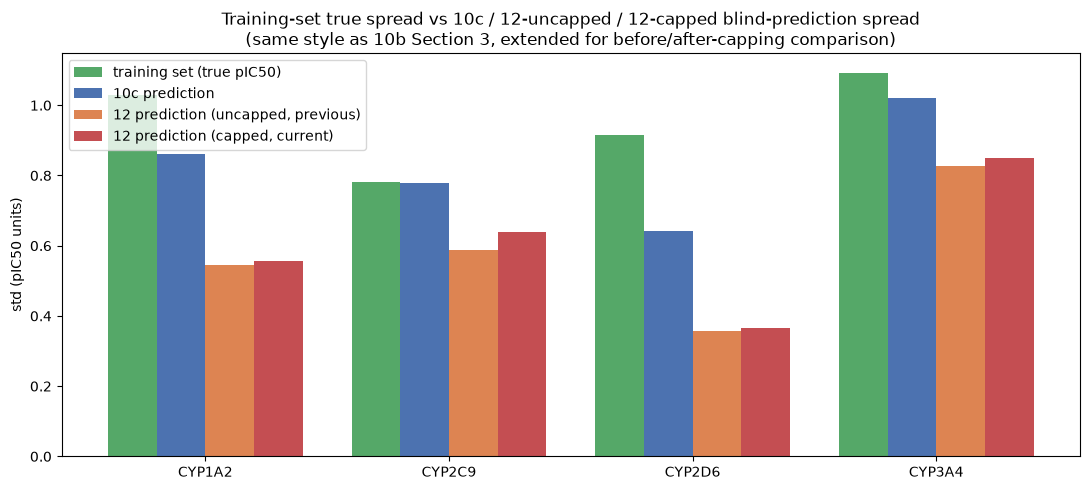

wrote /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/12b_caruana_vs_control_comparison/figures/spread_comparison.png


In [3]:
rows = []
for endpoint in REGRESSION_ENDPOINTS:
    iso = endpoint.split("_")[0]
    std_train = curated[endpoint].dropna().std()
    std_10c = merged[f"{endpoint}__10c"].std()
    std_12 = merged[f"{endpoint}__12"].std()
    std_12_uncapped = merged[f"{endpoint}__12_uncapped"].std()
    rows.append({
        "isoform": iso, "std_train": std_train, "std_10c": std_10c,
        "std_12": std_12, "std_12_uncapped": std_12_uncapped,
    })

spread_df = pd.DataFrame(rows)
spread_df["12_narrower_than_10c"] = spread_df["std_12"] < spread_df["std_10c"]
spread_df["capping_widened_spread"] = spread_df["std_12"] > spread_df["std_12_uncapped"]
print("Section 1 -- training-true std vs 10c/12-uncapped/12-capped prediction std:")
print(spread_df.to_string(index=False))

flagged = spread_df.loc[spread_df["12_narrower_than_10c"], "isoform"].tolist()
if flagged:
    print(f"\nFLAGGED -- 12 (capped)'s spread is STILL NARROWER than 10c's for: {flagged} "
          "(stated plainly, not softened)")
else:
    print("\nNo isoform shows 12 (capped)'s spread narrower than 10c's -- the specific notebook-10 pattern is fully resolved vs. 10c.")

widened = spread_df.loc[spread_df["capping_widened_spread"], "isoform"].tolist()
print(f"\nCapping widened spread (relative to the previous uncapped submission) for: {widened if widened else 'NONE -- capping did not widen blind-set spread for any isoform'}")

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(spread_df))
width = 0.2
ax.bar(x - 1.5 * width, spread_df["std_train"], width, label="training set (true pIC50)", color="#55A868")
ax.bar(x - 0.5 * width, spread_df["std_10c"], width, label="10c prediction", color="#4C72B0")
ax.bar(x + 0.5 * width, spread_df["std_12_uncapped"], width, label="12 prediction (uncapped, previous)", color="#DD8452")
ax.bar(x + 1.5 * width, spread_df["std_12"], width, label="12 prediction (capped, current)", color="#C44E52")
ax.set_xticks(x)
ax.set_xticklabels(spread_df["isoform"])
ax.set_ylabel("std (pIC50 units)")
ax.set_title("Training-set true spread vs 10c / 12-uncapped / 12-capped blind-prediction spread\n(same style as 10b Section 3, extended for before/after-capping comparison)")
ax.legend()
plt.tight_layout()
fig_path = FIG_OUT / "spread_comparison.png"
fig.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"wrote {fig_path}")


**What this shows:** the orange (uncapped, previous) and red (capped,
current) bars sit side by side for direct comparison -- whether the red bar
is visibly taller than the orange one (confirming capping widened spread, as
intended) is read directly off the chart, and confirmed numerically by the
printed `capping_widened_spread` column. Whether the capped (red) bar still
sits below 10c's (blue) is the original repeat-of-10 check, now against the
revised submission.

## Section 2 — agreement between 10c and 12 (capped)

Per isoform: Pearson correlation and mean absolute difference between 10c's
and 12's (capped) predictions on the same 750 compounds. High correlation +
low difference means 12 is a mild refinement of 10c; low correlation or a
large systematic difference means 12 is doing something meaningfully
different. As a first check on *why*, each isoform's non-chemprop Caruana
weight share is pulled from `outputs/11b_caruana_selection/weights.csv`
(now the capped version) -- 10c is 100% `chemprop_chemeleoninit`, so the
more weight notebook 12 puts on non-chemprop configs for an isoform, the
more divergence from 10c is mechanically expected.

In [4]:
weights = pd.read_csv(WEIGHTS_PATH)
print(f"loaded {WEIGHTS_PATH.relative_to(REPO_ROOT)}: {weights.shape} (capped)")

rows = []
for endpoint in REGRESSION_ENDPOINTS:
    iso = endpoint.split("_")[0]
    x = merged[f"{endpoint}__10c"].to_numpy()
    y = merged[f"{endpoint}__12"].to_numpy()
    r, _ = pearsonr(x, y)
    mean_abs_diff = float(np.mean(np.abs(x - y)))

    iso_weights = weights[(weights["isoform"] == iso) & (weights["weight"] > 0)]
    chemprop_weight = iso_weights.loc[iso_weights["config"] == "chemprop_chemeleoninit", "weight"].sum()
    non_chemprop_weight = float(iso_weights["weight"].sum() - chemprop_weight)

    rows.append({
        "isoform": iso, "correlation": r, "mean_abs_diff": mean_abs_diff,
        "non_chemprop_weight_share": non_chemprop_weight,
    })

agreement_df = pd.DataFrame(rows)
print("\nSection 2 -- 10c vs 12 (capped) agreement, and 12's non-chemprop_chemeleoninit weight share:")
print(agreement_df.to_string(index=False))


loaded outputs/11b_caruana_selection/weights.csv: (44, 3) (capped)

Section 2 -- 10c vs 12 (capped) agreement, and 12's non-chemprop_chemeleoninit weight share:
isoform  correlation  mean_abs_diff  non_chemprop_weight_share
 CYP1A2     0.875862       0.373387                   0.817073
 CYP2C9     0.955888       0.229784                   0.612245
 CYP2D6     0.837382       0.320907                   0.900000
 CYP3A4     0.946644       0.376164                   0.742857


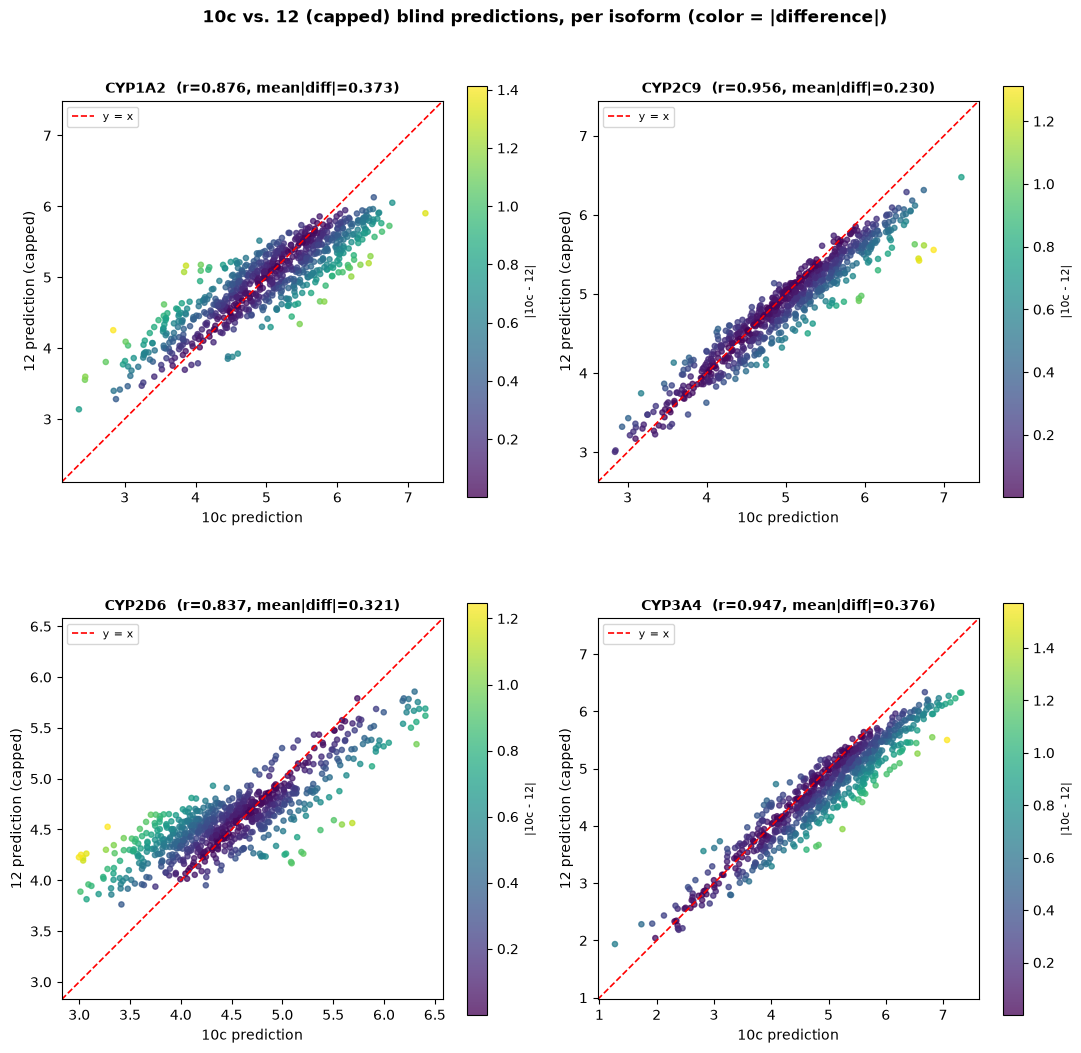

wrote /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/12b_caruana_vs_control_comparison/figures/agreement_scatter.png


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(11, 11))
for ax, endpoint in zip(axes.flat, REGRESSION_ENDPOINTS):
    iso = endpoint.split("_")[0]
    x = merged[f"{endpoint}__10c"].to_numpy()
    y = merged[f"{endpoint}__12"].to_numpy()
    abs_diff = np.abs(x - y)

    sc = ax.scatter(x, y, c=abs_diff, cmap="viridis", s=14, alpha=0.75)
    lo, hi = min(x.min(), y.min()), max(x.max(), y.max())
    pad = 0.05 * (hi - lo)
    lims = (lo - pad, hi + pad)
    ax.plot(lims, lims, "r--", lw=1.2, label="y = x")
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_aspect("equal")
    ax.set_xlabel("10c prediction")
    ax.set_ylabel("12 prediction (capped)")
    row = agreement_df.set_index("isoform").loc[iso]
    ax.set_title(f"{iso}  (r={row['correlation']:.3f}, mean|diff|={row['mean_abs_diff']:.3f})", fontsize=10, fontweight="bold")
    ax.legend(loc="upper left", fontsize=8)
    cbar = fig.colorbar(sc, ax=ax, shrink=0.8)
    cbar.set_label("|10c - 12|", fontsize=8)

fig.suptitle("10c vs. 12 (capped) blind predictions, per isoform (color = |difference|)", fontsize=12, fontweight="bold")
plt.tight_layout()
fig_path = FIG_OUT / "agreement_scatter.png"
fig.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"wrote {fig_path}")


**What this shows:** all four isoforms' point clouds sit close to the y=x
line at the correlations printed above -- how tightly, and whether any
isoform's high-weight non-chemprop share (Section 2's table) tracks visibly
looser agreement, is read directly off the printed numbers and the color
gradient in each panel.

## Section 3 — where do they disagree most? (descriptive only, capped vs. 10c)

The 5 compounds with the largest `|10c - 12|` difference per isoform. **No
true label exists to check these against yet** -- this is purely a record
for later: once the 3 Nov 2026 labels are released, these are the compounds
to check first.

In [6]:
top_disagreements = []
for endpoint in REGRESSION_ENDPOINTS:
    iso = endpoint.split("_")[0]
    sub = merged[["Molecule_Name", f"{endpoint}__10c", f"{endpoint}__12"]].copy()
    sub["abs_diff"] = (sub[f"{endpoint}__10c"] - sub[f"{endpoint}__12"]).abs()
    sub["isoform"] = iso
    sub = sub.rename(columns={f"{endpoint}__10c": "pred_10c", f"{endpoint}__12": "pred_12"})
    top5 = sub.sort_values("abs_diff", ascending=False).head(5)
    top_disagreements.append(top5[["isoform", "Molecule_Name", "pred_10c", "pred_12", "abs_diff"]])

    print(f"\n=== {iso}: top 5 compounds by |10c - 12(capped)| ===")
    print(top5[["Molecule_Name", "pred_10c", "pred_12", "abs_diff"]].to_string(index=False))

top_disagreements_df = pd.concat(top_disagreements, ignore_index=True)
top_disagreements_path = OUT / "top_disagreements.csv"
top_disagreements_df.to_csv(top_disagreements_path, index=False)
print(f"\nwrote {top_disagreements_path} ({top_disagreements_df.shape}) -- kept on record for once 3-Nov labels exist (OVERWRITES the pre-revision version)")



=== CYP1A2: top 5 compounds by |10c - 12(capped)| ===
Molecule_Name  pred_10c  pred_12  abs_diff
 OCNT-2535134  2.839747 4.253684  1.413937
 OCNT-2535006  7.241630 5.902675  1.338954
 OCNT-2535659  3.865648 5.163397  1.297749
 OCNT-2534966  6.442568 5.198177  1.244391
 OCNT-2535662  3.838767 5.074203  1.235437

=== CYP2C9: top 5 compounds by |10c - 12(capped)| ===
Molecule_Name  pred_10c  pred_12  abs_diff
 OCNT-2534913  6.869696 5.556633  1.313063
 OCNT-2534919  6.686433 5.421548  1.264885
 OCNT-2534915  6.678035 5.447388  1.230647
 OCNT-2534921  6.747429 5.613892  1.133537
 OCNT-2535612  5.924622 4.912558  1.012064

=== CYP2D6: top 5 compounds by |10c - 12(capped)| ===
Molecule_Name  pred_10c  pred_12  abs_diff
 OCNT-2535284  3.279633 4.526218  1.246586
 OCNT-2535247  3.017410 4.251098  1.233688
 OCNT-2535690  2.997245 4.226620  1.229374
 OCNT-2535382  3.070711 4.262704  1.191993
 OCNT-2535071  3.038088 4.219211  1.181123

=== CYP3A4: top 5 compounds by |10c - 12(capped)| ===
Molecu

## Section 4 — explicit per-isoform summary

Stated plainly per this task's own instruction: whether 12 (capped) repeats
or avoids the spread-compression pattern (both vs. 10c and vs. its own
uncapped predecessor), and how different 12's predictions are from 10c's in
practical terms. No editorializing about expected leaderboard outcome
beyond that -- this notebook cannot forecast that.

**Cutoff note, flagged rather than silently picked (unchanged from the
original version of this notebook):** the task described the agreement read
qualitatively without giving numeric thresholds. The cell below uses
illustrative cutoffs (r>=0.95 and mean|diff|<0.15 for "mild refinement",
r>=0.85 for "broadly similar", otherwise "meaningfully different") purely to
generate readable summary text -- not a pre-registered or task-specified
threshold. The actual numbers are printed alongside every verdict below and
in `summary.csv`.

In [7]:
summary_df = spread_df.merge(agreement_df, on="isoform", how="left")
summary_df = summary_df[[
    "isoform", "std_10c", "std_12", "std_12_uncapped", "std_train", "correlation", "mean_abs_diff",
    "12_narrower_than_10c", "capping_widened_spread", "non_chemprop_weight_share",
]]
summary_df = summary_df.rename(columns={"std_10c": "10c_std", "std_12": "12_std", "std_train": "true_std"})
summary_path = OUT / "summary.csv"
summary_df.to_csv(summary_path, index=False)
print(f"wrote {summary_path} (OVERWRITES the pre-revision version)")
print(summary_df.to_string(index=False))


wrote /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/12b_caruana_vs_control_comparison/summary.csv (OVERWRITES the pre-revision version)
isoform  10c_std   12_std  std_12_uncapped  true_std  correlation  mean_abs_diff  12_narrower_than_10c  capping_widened_spread  non_chemprop_weight_share
 CYP1A2 0.861623 0.555969         0.545521  1.030476     0.875862       0.373387                  True                    True                   0.817073
 CYP2C9 0.778405 0.638953         0.588060  0.782295     0.955888       0.229784                  True                    True                   0.612245
 CYP2D6 0.641710 0.365271         0.357932  0.916096     0.837382       0.320907                  True                    True                   0.900000
 CYP3A4 1.019663 0.848695         0.828203  1.093219     0.946644       0.376164                  True                    True                   0.742857


In [8]:
from IPython.display import Markdown, display

lines = []
for _, row in summary_df.iterrows():
    iso = row["isoform"]
    cap_effect = "**widened**" if row["capping_widened_spread"] else "did **not** widen"
    if row["12_narrower_than_10c"]:
        spread_verdict = (
            f"still **repeats** the spread-compression pattern vs. 10c (12's std {row['12_std']:.4f} < 10c's {row['10c_std']:.4f}; "
            f"training-true std is {row['true_std']:.4f}), though capping {cap_effect} spread relative to the uncapped predecessor "
            f"({row['std_12_uncapped']:.4f} -> {row['12_std']:.4f})"
        )
    else:
        spread_verdict = (
            f"now **avoids** the spread-compression pattern vs. 10c (12's std {row['12_std']:.4f} >= 10c's {row['10c_std']:.4f}; "
            f"training-true std is {row['true_std']:.4f}); capping {cap_effect} spread relative to the uncapped predecessor "
            f"({row['std_12_uncapped']:.4f} -> {row['12_std']:.4f})"
        )

    r = row["correlation"]
    mad = row["mean_abs_diff"]
    ncw = row["non_chemprop_weight_share"]
    if r >= 0.95 and mad < 0.15:
        agreement_verdict = f"a **mild refinement** of 10c (r={r:.3f}, mean|diff|={mad:.3f} pIC50 units)"
    elif r >= 0.85:
        agreement_verdict = f"**broadly similar but non-trivially different** from 10c (r={r:.3f}, mean|diff|={mad:.3f} pIC50 units)"
    else:
        agreement_verdict = f"**meaningfully different** from 10c (r={r:.3f}, mean|diff|={mad:.3f} pIC50 units)"

    lines.append(
        f"- **{iso}**: 12 (capped) {spread_verdict}. Its predictions are {agreement_verdict} -- "
        f"{ncw * 100:.1f}% of its (capped) Caruana weight sits on non-`chemprop_chemeleoninit` configs "
        f"(10c is 100% `chemprop_chemeleoninit`), which mechanically bounds how close agreement with 10c can be."
    )

display(Markdown("\n".join(lines)))


- **CYP1A2**: 12 (capped) still **repeats** the spread-compression pattern vs. 10c (12's std 0.5560 < 10c's 0.8616; training-true std is 1.0305), though capping **widened** spread relative to the uncapped predecessor (0.5455 -> 0.5560). Its predictions are **broadly similar but non-trivially different** from 10c (r=0.876, mean|diff|=0.373 pIC50 units) -- 81.7% of its (capped) Caruana weight sits on non-`chemprop_chemeleoninit` configs (10c is 100% `chemprop_chemeleoninit`), which mechanically bounds how close agreement with 10c can be.
- **CYP2C9**: 12 (capped) still **repeats** the spread-compression pattern vs. 10c (12's std 0.6390 < 10c's 0.7784; training-true std is 0.7823), though capping **widened** spread relative to the uncapped predecessor (0.5881 -> 0.6390). Its predictions are **broadly similar but non-trivially different** from 10c (r=0.956, mean|diff|=0.230 pIC50 units) -- 61.2% of its (capped) Caruana weight sits on non-`chemprop_chemeleoninit` configs (10c is 100% `chemprop_chemeleoninit`), which mechanically bounds how close agreement with 10c can be.
- **CYP2D6**: 12 (capped) still **repeats** the spread-compression pattern vs. 10c (12's std 0.3653 < 10c's 0.6417; training-true std is 0.9161), though capping **widened** spread relative to the uncapped predecessor (0.3579 -> 0.3653). Its predictions are **meaningfully different** from 10c (r=0.837, mean|diff|=0.321 pIC50 units) -- 90.0% of its (capped) Caruana weight sits on non-`chemprop_chemeleoninit` configs (10c is 100% `chemprop_chemeleoninit`), which mechanically bounds how close agreement with 10c can be.
- **CYP3A4**: 12 (capped) still **repeats** the spread-compression pattern vs. 10c (12's std 0.8487 < 10c's 1.0197; training-true std is 1.0932), though capping **widened** spread relative to the uncapped predecessor (0.8282 -> 0.8487). Its predictions are **broadly similar but non-trivially different** from 10c (r=0.947, mean|diff|=0.376 pIC50 units) -- 74.3% of its (capped) Caruana weight sits on non-`chemprop_chemeleoninit` configs (10c is 100% `chemprop_chemeleoninit`), which mechanically bounds how close agreement with 10c can be.